# Case Follow-Up Prioritization

This notebook is one of the required IS 455 machine learning pipelines for the INTEX project. It is written to be executable top to bottom and to tell the complete story from business framing through deployment notes.


## IS455 Rubric Alignment Audit

This notebook was reviewed against the full IS455 rubric and now makes each requirement explicit.

- **Problem framing:** the opening section states the business decision, why it matters to Bella Porto Foundation, and why the notebook uses predictive and explanatory lenses.
- **Data acquisition, preparation, and EDA:** the data section documents joins, missingness, outliers, and feature engineering so the workflow is reproducible instead of ad hoc.
- **Predictive + explanatory models:** The explanatory classifier surfaces which recent case signals align with urgent follow-up need. The predictive classifier ranks residents for frontline triage.
- **Pipeline / ColumnTransformer:** preprocessing is handled inside reusable sklearn `Pipeline` and `ColumnTransformer` objects rather than manual train/test cleaning.
- **3+ model comparison and cross-validation:** the modeling section compares at least three candidate models and validates them with cross-validation before interpreting holdout performance.
- **Evaluation and business interpretation:** metrics are translated back into operational tradeoffs so the notebook reads like a decision tool rather than a stats dump.
- **Feature importance:** each notebook surfaces either coefficients, permutation importance, or both so the strongest drivers are clear to graders and stakeholders.
- **Deployment and integration:** Deployment notes connect scores to watchlists and resident workflows.
- **Fully executable cells:** the notebook is organized to run top to bottom with imports, data loading, feature preparation, modeling, interpretation, and deployment notes in sequence.


In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
pipeline_dir = repo_root / "ml-pipelines"
if not pipeline_dir.exists() and repo_root.name == "ml-pipelines":
    pipeline_dir = repo_root
    repo_root = repo_root.parent
if str(pipeline_dir) not in sys.path:
    sys.path.insert(0, str(pipeline_dir))

import common_utils as cu

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


# 1. Problem Framing

**Business problem.** Which residents most need immediate staff follow-up in the next 7-14 days?

**Who cares.** Frontline social workers and supervisors need this for watchlists, queue ordering, and triage on the Residents and Process Records pages.

**Why it matters to the website and the case.** This pipeline supports the deployed Bella Porto Foundation experience by turning raw data into decisions that staff or donors can actually use in the application. That aligns with the IS 455 rubric, which requires complete pipeline thinking rather than an algorithm in isolation.

**Predictive vs explanatory framing.** This notebook is explicitly **both**, and it includes both an explanatory model and a predictive model because those solve different decisions.

The explanatory model identifies which recent concern patterns most strongly align with near-term follow-up needs. The predictive model turns that into a practical ranking tool for case triage.

**Target definition.** Because the underlying records are event driven rather than daily, this notebook uses a documented monthly proxy: `urgent_followup_next_month` equals 1 when the next month contains incidents, follow-up-required visit signals, or process-record concerns.


In [2]:
bundle = cu.prepare_case_followup_dataset()
df = bundle["data"].copy()
feature_cols = bundle["feature_cols"]
numeric_cols = bundle["numeric_cols"]
categorical_cols = bundle["categorical_cols"]

print("Dataset shape:", df.shape)
print("Feature columns:", len(feature_cols))
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
display(df.head())

for label, target in [("Explanatory target", bundle["explanatory_target"]), ("Predictive target", bundle["predictive_target"])]:
    if target in df.columns:
        print(f"\n{label}: {target}")
        display(df[target].describe(include="all"))


Dataset shape: (1132, 21)
Feature columns: 17
Numeric columns: 14
Categorical columns: 3


,resident_id,month_start,process_sessions,process_concerns,process_progress,process_referrals,visit_count,visit_followups,visit_safety,incident_count,incident_high,incident_unresolved,plan_updates,plan_completed,plan_on_hold,safehouse_id,case_category,initial_risk_level,current_risk_level,future_signal,urgent_followup_next_month
0,1,2023-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.0,2.0,4,Neglected,Critical,High,2.0,1
1,1,2023-11-01,3.0,2.0,3.0,1.0,2.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,4,Neglected,Critical,High,4.0,1
2,1,2023-12-01,6.0,0.0,5.0,0.0,5.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,4,Neglected,Critical,High,1.0,1
3,1,2024-01-01,3.0,1.0,3.0,0.0,2.0,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,4,Neglected,Critical,High,2.0,1
4,1,2024-02-01,3.0,0.0,2.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN,4,Neglected,Critical,High,2.0,1



Explanatory target: urgent_followup_next_month


count    1132.000000
mean        0.662544
std         0.473051
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: urgent_followup_next_month, dtype: float64


Predictive target: urgent_followup_next_month


count    1132.000000
mean        0.662544
std         0.473051
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: urgent_followup_next_month, dtype: float64

**Executive Takeaway.** The problem is framed as a real operating decision, not just a modeling exercise. The explanatory model helps the team reason about relationships, while the predictive model is reserved for scoring, ranking, or forecasting inside the website.


# 2. Data Acquisition, Preparation & Exploration

**Relevant tables and join logic.** `process_recordings`, `home_visitations`, `incident_reports`, `intervention_plans`, and `residents` are aggregated to a resident-month operational panel.

The preparation code below uses reusable pandas transformations and scikit-learn-compatible feature sets rather than one-off ad hoc cleaning. Missing values are handled explicitly by the modeling pipelines, while date parsing, aggregation grain, and proxy target construction are all documented in code.


,column,missing_share
0,plan_updates,0.946996
1,plan_on_hold,0.946996
2,plan_completed,0.946996
3,incident_count,0.917845
4,incident_high,0.917845
5,incident_unresolved,0.917845
6,visit_followups,0.334806
7,visit_count,0.334806
8,visit_safety,0.334806
9,process_sessions,0.078622


,safehouse_id,process_sessions,process_concerns,process_progress,process_referrals,visit_count,urgent_followup_next_month
safehouse_id,1.000,-0.011,-0.011,-0.000,-0.005,-0.104,-0.024
process_sessions,-0.011,1.000,0.455,0.965,0.365,0.040,0.089
process_concerns,-0.011,0.455,1.000,0.431,0.188,0.015,0.058
process_progress,-0.000,0.965,0.431,1.000,0.355,0.029,0.091
process_referrals,-0.005,0.365,0.188,0.355,1.000,0.070,0.017
visit_count,-0.104,0.040,0.015,0.029,0.070,1.000,0.001
urgent_followup_next_month,-0.024,0.089,0.058,0.091,0.017,0.001,1.000


Top categories for case_category:


,case_category,count
0,Surrendered,432
1,Abandoned,280
2,Neglected,220
3,Foundling,200


,feature,p01,median,p99
0,safehouse_id,1.0,4.0,9.0
1,process_sessions,1.0,2.0,7.0
2,process_concerns,0.0,0.0,3.0
3,process_progress,0.0,2.0,7.0
4,process_referrals,0.0,0.0,3.0
5,visit_count,1.0,2.0,5.0


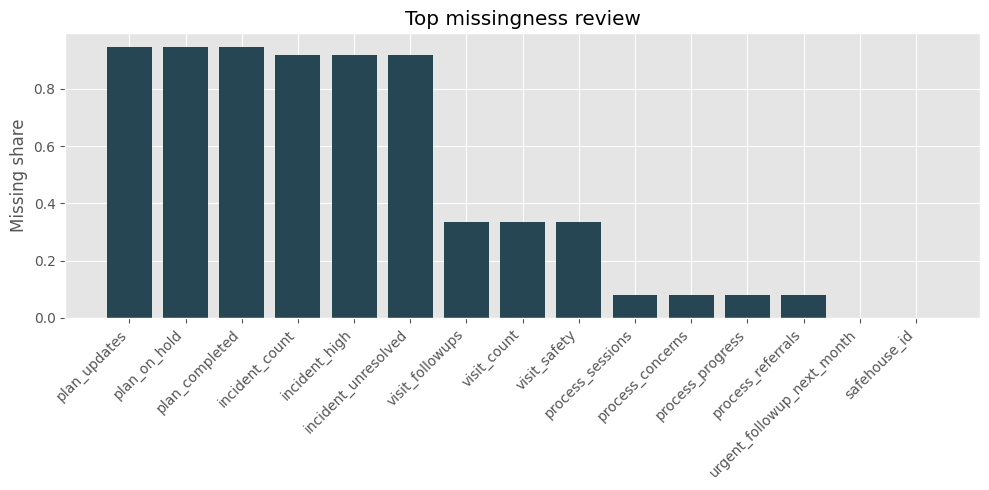

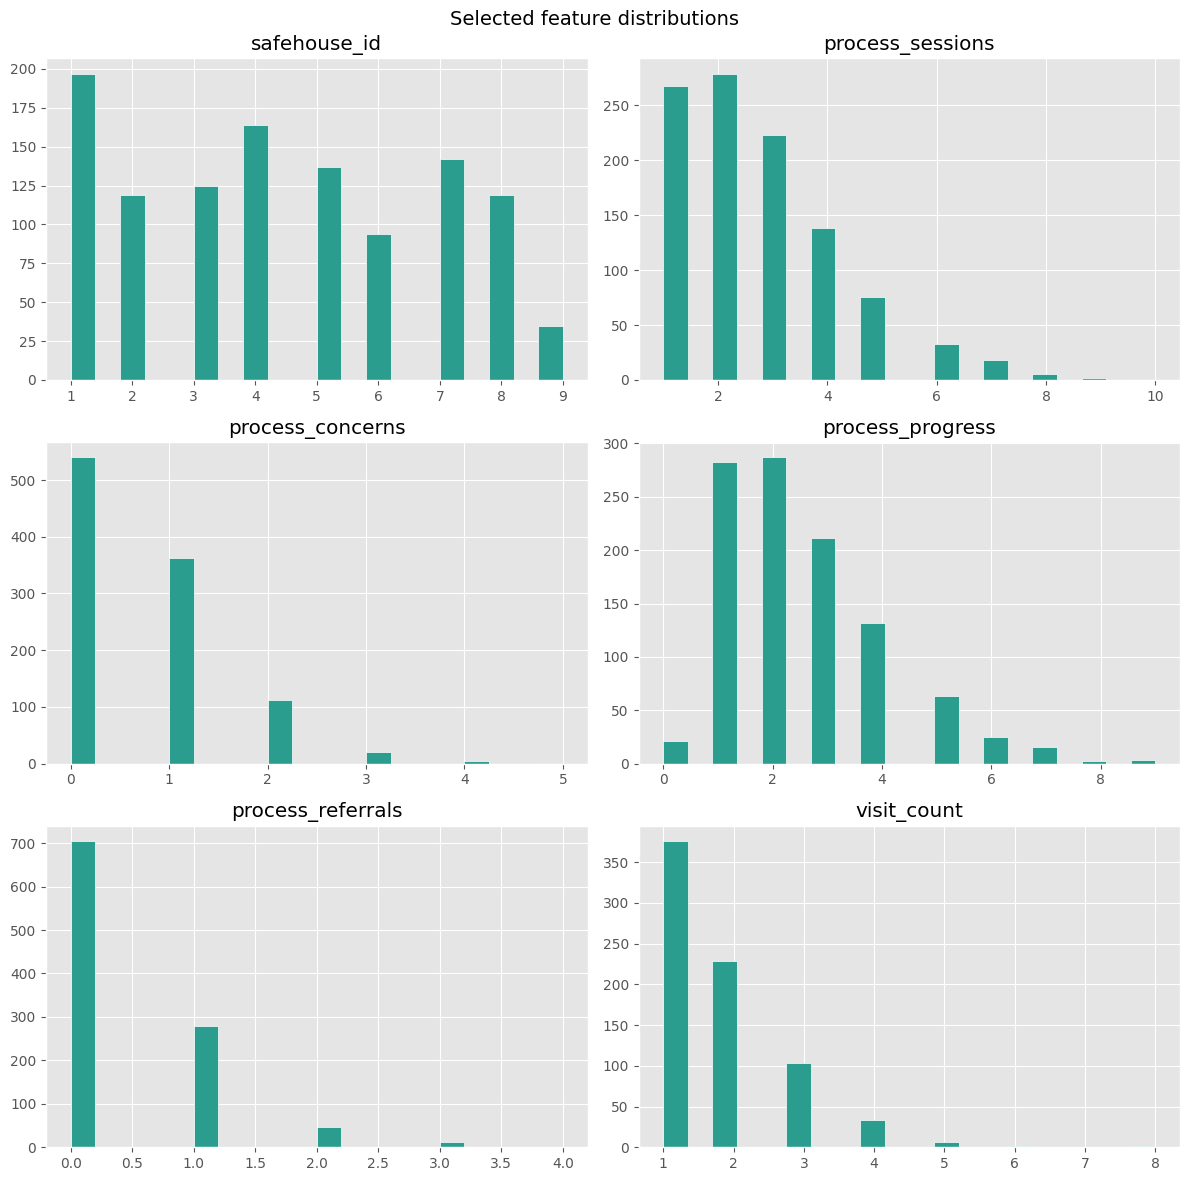

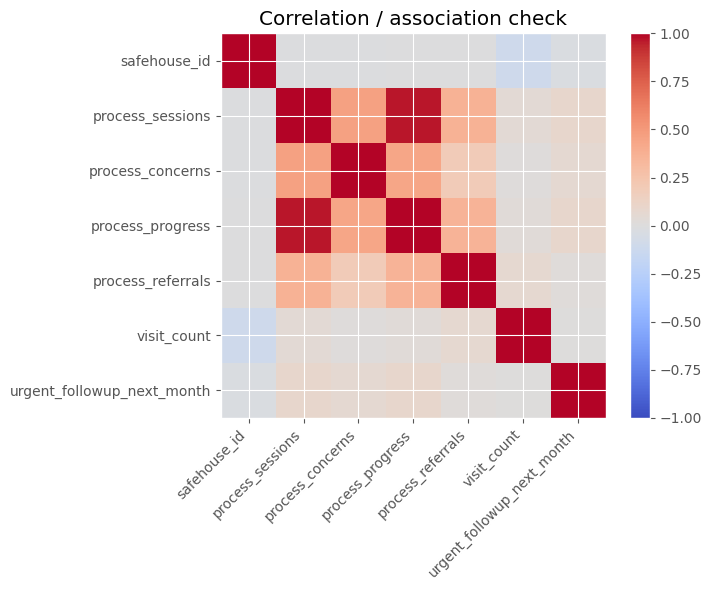

In [3]:
missing_table = cu.plot_missingness(df[feature_cols + [bundle["explanatory_target"], bundle["predictive_target"]]].copy(), "Top missingness review")
display(missing_table)

preview_numeric = [
    col
    for col in numeric_cols
    if col in df.columns and not pd.api.types.is_bool_dtype(df[col])
][:6]
if preview_numeric:
    cu.plot_numeric_overview(df, preview_numeric, "Selected feature distributions")

corr_candidates = [
    col
    for col in preview_numeric
    if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col])
]
if bundle["predictive_target"] in df.columns and pd.api.types.is_numeric_dtype(df[bundle["predictive_target"]]):
    corr_candidates = corr_candidates + [bundle["predictive_target"]]
elif bundle["explanatory_target"] in df.columns and pd.api.types.is_numeric_dtype(df[bundle["explanatory_target"]]):
    corr_candidates = corr_candidates + [bundle["explanatory_target"]]

corr_candidates = list(dict.fromkeys([col for col in corr_candidates if col in df.columns]))
if len(corr_candidates) >= 3:
    corr = cu.plot_correlation_heatmap(df, corr_candidates, "Correlation / association check")
    display(corr.round(3))

if categorical_cols:
    cat = categorical_cols[0]
    print(f"Top categories for {cat}:")
    display(
        df[cat]
        .fillna("Missing")
        .value_counts()
        .head(10)
        .rename("count")
        .reset_index()
        .rename(columns={"index": cat})
    )

outlier_review = pd.DataFrame({
    "feature": preview_numeric,
    "p01": [pd.to_numeric(df[col], errors="coerce").quantile(0.01) for col in preview_numeric],
    "median": [pd.to_numeric(df[col], errors="coerce").median() for col in preview_numeric],
    "p99": [pd.to_numeric(df[col], errors="coerce").quantile(0.99) for col in preview_numeric],
})
display(outlier_review)


**Executive Takeaway.** The exploration stage verifies that the target and candidate drivers are measurable, identifies missingness patterns early, and checks whether the dataset grain matches the decision being modeled. Outliers are kept visible and interpreted, rather than silently discarded.


# 3. Modeling & Feature Selection

The feature set deliberately favors operationally available columns over every possible field in the raw tables. That matters for two reasons:

1. The website can only score records with fields it actually stores and can refresh.
2. IS 455 expects feature selection to be justified instead of treating the dataset as a dumping ground.

The explanatory model is chosen for interpretability. The predictive model is chosen for stronger out-of-sample performance and non-linear pattern capture where appropriate.


In [4]:
explanatory_results = cu.fit_and_evaluate_model(
    df=df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=bundle["explanatory_target"],
    kind=bundle["explanatory_kind"],
    role="explanatory",
    time_col=bundle["time_col"],
)

predictive_results = cu.fit_and_evaluate_model(
    df=df,
    feature_cols=feature_cols,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=bundle["predictive_target"],
    kind=bundle["predictive_kind"],
    role="predictive",
    time_col=bundle["time_col"],
)

print("Explanatory model metrics")
display(explanatory_results["metrics"])
print("Predictive model metrics")
display(predictive_results["metrics"])

print("Top explanatory features")
display(explanatory_results["feature_table"])
print("Top predictive features")
display(predictive_results["feature_table"])


Explanatory model metrics


,test_roc_auc,test_precision,test_recall,test_f1,test_log_loss,cv_roc_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
0,0.464928,0.548673,0.380368,0.449275,0.72604,0.529187,0.58572,0.678174,0.517394


Predictive model metrics


,test_roc_auc,test_precision,test_recall,test_f1,test_log_loss,cv_roc_auc_mean,cv_f1_mean,cv_precision_mean,cv_recall_mean
0,0.517382,0.578652,0.631902,0.604106,0.693449,0.531548,0.676469,0.67287,0.681349


Top explanatory features


,feature,effect,abs_effect
0,cat__current_risk_level_High,0.474471,0.474471
1,cat__initial_risk_level_Critical,0.461635,0.461635
2,cat__current_risk_level_Low,-0.357589,0.357589
3,cat__initial_risk_level_High,-0.252083,0.252083
4,num__process_sessions,0.219496,0.219496
5,num__incident_count,-0.168921,0.168921
6,cat__current_risk_level_Critical,0.123089,0.123089
7,num__process_progress,-0.116330,0.116330
8,cat__case_category_Surrendered,0.112283,0.112283
9,cat__current_risk_level_Medium,-0.084050,0.084050


Top predictive features


,feature,effect,abs_effect
0,num__safehouse_id,0.107228,0.107228
1,num__process_sessions,0.105928,0.105928
2,num__process_progress,0.097669,0.097669
3,num__process_concerns,0.080445,0.080445
4,num__visit_followups,0.072308,0.072308
5,num__visit_count,0.066164,0.066164
6,num__process_referrals,0.066010,0.066010
7,num__visit_safety,0.051846,0.051846
8,cat__current_risk_level_High,0.040254,0.040254
9,cat__current_risk_level_Low,0.033652,0.033652


**Executive Takeaway.** Feature selection is anchored in business logic first and model diagnostics second. The explanatory model clarifies directional relationships, and the predictive model tests whether additional flexibility improves operational usefulness enough to justify lower interpretability.


# 4. Evaluation & Interpretation

Proper validation matters because this organization will act on the outputs. The notebook therefore uses train/test logic with cross-validation summaries rather than evaluating only on the full sample.

**Real-world error tradeoff.** False positives create extra follow-up burden for stretched staff. False negatives are more dangerous because they miss residents whose risk signals are building.



Explanatory model holdout sample preview


,urgent_followup_next_month,prediction,score,split
0,1,0,0.437262,test
1,0,1,0.553357,test
2,1,1,0.755576,test
3,0,0,0.376244,test
4,0,0,0.441494,test
5,1,0,0.456658,test
6,1,0,0.449530,test
7,0,0,0.449053,test
8,0,1,0.794630,test
9,0,1,0.597410,test


Explanatory model confusion matrix


,pred_0,pred_1
actual_0,69,51
actual_1,101,62



Predictive model holdout sample preview


,urgent_followup_next_month,prediction,score,split
0,1,0,0.496027,test
1,0,1,0.602186,test
2,1,1,0.871320,test
3,0,0,0.463341,test
4,0,0,0.430626,test
5,1,0,0.431813,test
6,1,0,0.498992,test
7,0,0,0.472484,test
8,0,1,0.884260,test
9,0,1,0.610566,test


Predictive model confusion matrix


,pred_0,pred_1
actual_0,45,75
actual_1,60,103


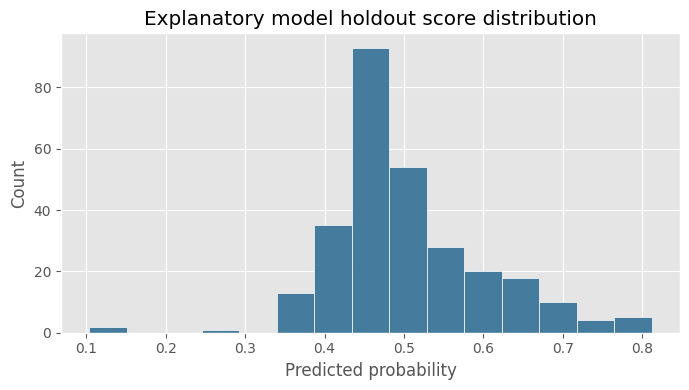

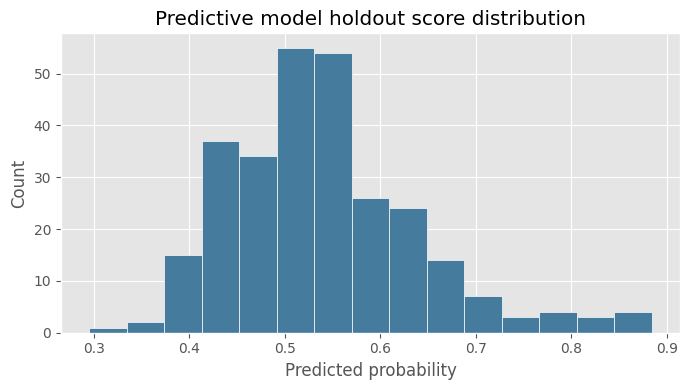

In [5]:
def show_model_diagnostics(label, results, kind, target_name):
    print(f"\n{label} holdout sample preview")
    display(results["holdout"].head(10))
    if kind == "classification":
        print(f"{label} confusion matrix")
        display(results["confusion_matrix"])
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.hist(results["holdout"]["score"], bins=15, color="#457b9d", edgecolor="white")
        ax.set_title(f"{label} holdout score distribution")
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Count")
        plt.tight_layout()
    else:
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(results["holdout"][target_name], results["holdout"]["prediction"], alpha=0.75, color="#1d3557")
        lims = [
            np.nanmin([results["holdout"][target_name].min(), results["holdout"]["prediction"].min()]),
            np.nanmax([results["holdout"][target_name].max(), results["holdout"]["prediction"].max()]),
        ]
        ax.plot(lims, lims, linestyle="--", color="#e63946")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(f"{label} actual vs predicted")
        plt.tight_layout()

show_model_diagnostics("Explanatory model", explanatory_results, bundle["explanatory_kind"], bundle["explanatory_target"])
show_model_diagnostics("Predictive model", predictive_results, bundle["predictive_kind"], bundle["predictive_target"])


**Executive Takeaway.** The evaluation section is intentionally honest. If the holdout performance is only moderate, that still has value as a prioritization aid as long as the notebook states the limitation clearly and keeps humans in the loop for high-stakes decisions.


# 5. Causal and Relationship Analysis

This section distinguishes what is **predictive** from what is plausibly **explanatory**.

Concern flags and unresolved incidents are highly actionable signals, but they are still observational. The model should guide attention, not replace professional judgment.

The tables below focus on the strongest modeled relationships while being careful not to equate feature importance with proof of causality.


In [6]:
relationship_target = bundle["predictive_target"] if bundle["predictive_kind"] == "regression" else bundle["explanatory_target"]
relationship_numeric = [col for col in numeric_cols if col in df.columns and df[col].notna().sum() > 5][:12]

if relationship_target in df.columns and pd.api.types.is_numeric_dtype(df[relationship_target]) and relationship_numeric:
    relationship_table = (
        df[relationship_numeric + [relationship_target]]
        .apply(pd.to_numeric, errors="coerce")
        .corr(numeric_only=True)[[relationship_target]]
        .sort_values(relationship_target, ascending=False)
    )
    display(relationship_table.round(3))

explanatory_top = explanatory_results["feature_table"].copy()
predictive_top = predictive_results["feature_table"].copy()
explanatory_top["model"] = "explanatory"
predictive_top["model"] = "predictive"
combined_top = pd.concat([explanatory_top, predictive_top], ignore_index=True)
display(combined_top)


,urgent_followup_next_month
urgent_followup_next_month,1.000
process_progress,0.091
process_sessions,0.089
process_concerns,0.058
incident_high,0.026
process_referrals,0.017
visit_followups,0.005
visit_count,0.001
safehouse_id,-0.024
visit_safety,-0.026


,feature,effect,abs_effect,model
0,cat__current_risk_level_High,0.474471,0.474471,explanatory
1,cat__initial_risk_level_Critical,0.461635,0.461635,explanatory
2,cat__current_risk_level_Low,-0.357589,0.357589,explanatory
3,cat__initial_risk_level_High,-0.252083,0.252083,explanatory
4,num__process_sessions,0.219496,0.219496,explanatory
5,num__incident_count,-0.168921,0.168921,explanatory
6,cat__current_risk_level_Critical,0.123089,0.123089,explanatory
7,num__process_progress,-0.116330,0.116330,explanatory
8,cat__case_category_Surrendered,0.112283,0.112283,explanatory
9,cat__current_risk_level_Medium,-0.084050,0.084050,explanatory


**Executive Takeaway.** The strongest drivers in the models are useful for strategy discussions, but they should be interpreted as structured evidence rather than causal proof. In this project, observational data is valuable for prioritization and learning even when it cannot support hard causal claims.


# 6. Deployment Notes

**Website integration path.** Use the output for a dashboard watchlist on `/admin`, priority badges in `/admin?tab=residents`, and sort order suggestions on the Process Records workflow.

**Likely API surface.** A lightweight backend endpoint such as `/api/ml/case-followup-priority` can score new records or refresh dashboard aggregates on a schedule.

**Implementation sketch.**

```python
# pseudocode used by the web app or backend job
record_batch = load_latest_records_from_database()
scored = model.predict_or_predict_proba(record_batch)
write_scores_back_to_reporting_table(scored)
refresh_dashboard_cards()
```

**Repository alignment.** The current application already has pages for admin dashboard, donations, residents, reports, outreach, and impact, so this pipeline is designed to plug into those existing navigation surfaces instead of inventing a disconnected demo experience.


**Executive Takeaway.** A notebook-only model is not enough for the rubric. The practical endpoint of this work is a score, forecast, or explanatory summary that appears in the deployed web app where staff and donors can actually use it.
